In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"D:\bits course\assignment 3\part4\student data.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 15 non-null     object 
 1   math                 15 non-null     int64  
 2   science              15 non-null     int64  
 3   english              15 non-null     int64  
 4   history              15 non-null     int64  
 5   pe                   15 non-null     int64  
 6   attendance_pct       15 non-null     int64  
 7   study_hours_per_day  15 non-null     float64
 8   passed               15 non-null     int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ KB


In [16]:
df["total_marks"] = df[["math","science","english","history","pe"]].sum(axis=1)

df["average"] = df["total_marks"] / 5

print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  total_marks  average  
0                  4.5       1          431     86.2  
1                  1.2       0          255     51.0  
2                  3.0       1          381     76.2  
3                  6.0       1          470     94.0  
4                  0.8       0          230     46.0  


In [9]:
df.columns

Index(['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct',
       'study_hours_per_day', 'passed'],
      dtype='object')

In [11]:
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [14]:
print(df.isnull().sum())

name                   0
math                   0
science                0
english                0
history                0
pe                     0
attendance_pct         0
study_hours_per_day    0
passed                 0
dtype: int64


In [30]:
df_numeric = df.select_dtypes(include=["number"])

corr = df_numeric.corr()

print(corr)

                         math   science   english   history        pe  \
math                 1.000000  0.965064  0.927563  0.970470  0.988433   
science              0.965064  1.000000  0.898960  0.968478  0.962000   
english              0.927563  0.898960  1.000000  0.891722  0.946418   
history              0.970470  0.968478  0.891722  1.000000  0.962968   
pe                   0.988433  0.962000  0.946418  0.962968  1.000000   
attendance_pct       0.972015  0.982022  0.956148  0.959752  0.982875   
study_hours_per_day  0.971427  0.976029  0.914082  0.964910  0.951447   
passed               0.835579  0.790146  0.920928  0.751869  0.852408   
total_marks          0.991374  0.979844  0.952363  0.979074  0.992623   
average              0.991374  0.979844  0.952363  0.979074  0.992623   

                     attendance_pct  study_hours_per_day    passed  \
math                       0.972015             0.971427  0.835579   
science                    0.982022             0.976029

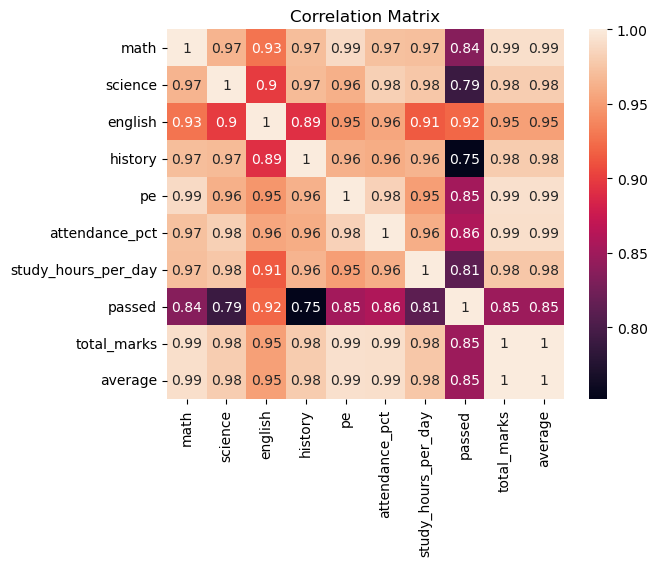

In [31]:
sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

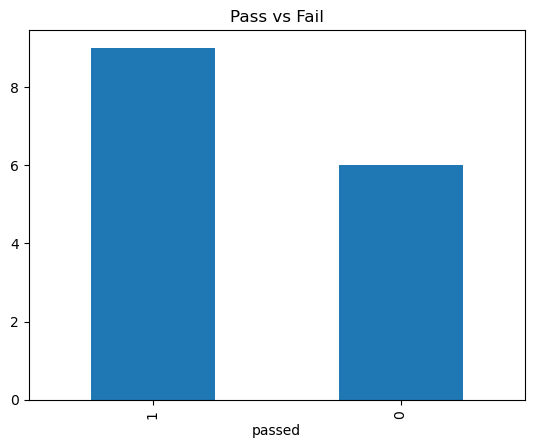

In [17]:
# TASK 2 — Matplotlib
df["passed"].value_counts().plot(kind="bar")
plt.title("Pass vs Fail")
plt.savefig("plot1_bar.png")
plt.show()

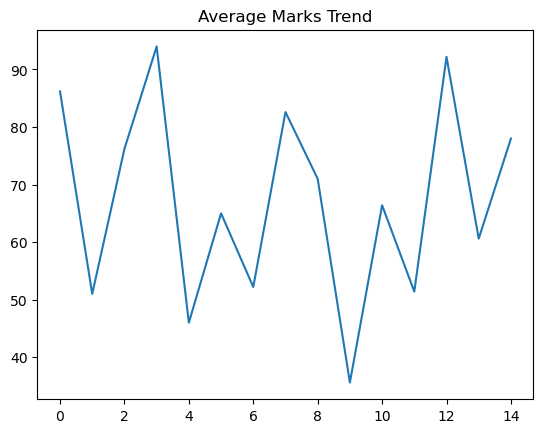

In [18]:
df["average"].plot(kind="line")
plt.title("Average Marks Trend")
plt.savefig("plot2_line.png")
plt.show()

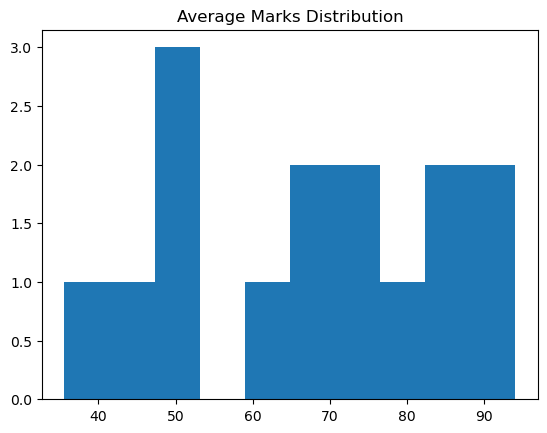

In [19]:
plt.hist(df["average"])
plt.title("Average Marks Distribution")
plt.savefig("plot3_hist.png")
plt.show()

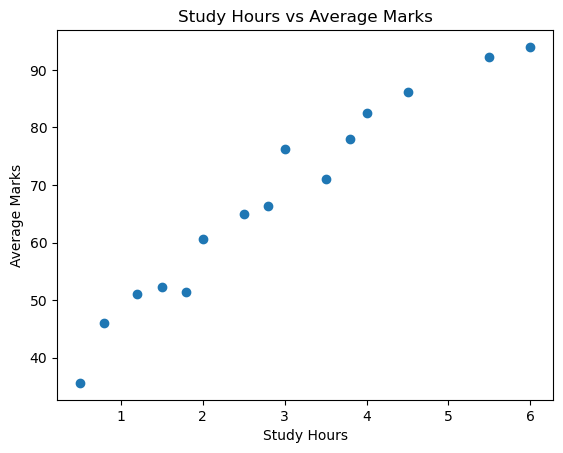

In [20]:
plt.scatter(df["study_hours_per_day"], df["average"])
plt.title("Study Hours vs Average Marks")
plt.xlabel("Study Hours")
plt.ylabel("Average Marks")
plt.savefig("plot4_scatter.png")
plt.show()

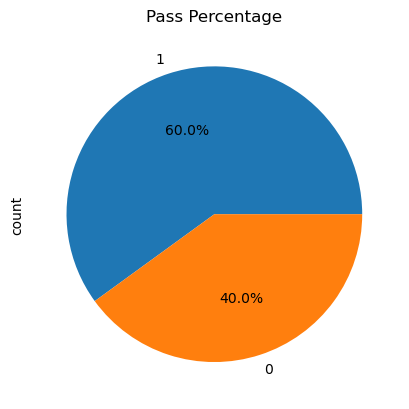

In [21]:
df["passed"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pass Percentage")
plt.savefig("plot5_pie.png")
plt.show()

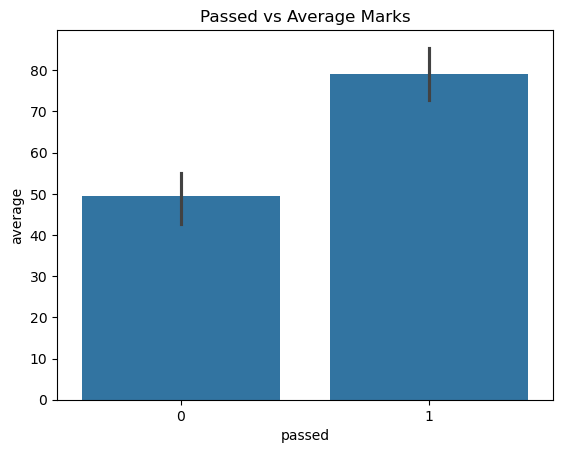

In [22]:
#TASK 3 — Seaborn
sns.barplot(x="passed", y="average", data=df)
plt.title("Passed vs Average Marks")
plt.savefig("plot6_seaborn_bar.png")
plt.show()

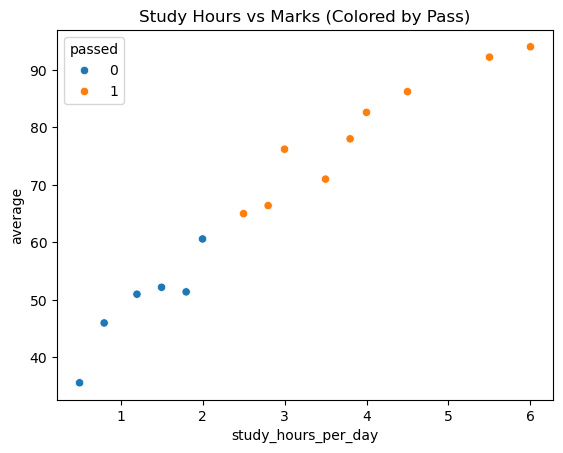

In [23]:
sns.scatterplot(x="study_hours_per_day", y="average", hue="passed", data=df)
plt.title("Study Hours vs Marks (Colored by Pass)")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [24]:
#TASK 4 — Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score    
X = df[["study_hours_per_day"]]
y = df["average"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


Mean Squared Error: 47.3116570692479
R² Score: 0.8941057752165532


In [25]:
pred = model.predict(X_test)

print("Predictions:", pred)

Predictions: [45.31952663 57.69780717 83.40654368]


In [26]:
score = model.score(X_test, y_test)
print("Model Accuracy (R2 Score):", score)

Model Accuracy (R2 Score): 0.8941057752165532


In [27]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
})

print(result)

   Actual  Predicted
0    35.6  45.319527
1    51.4  57.697807
2    86.2  83.406544


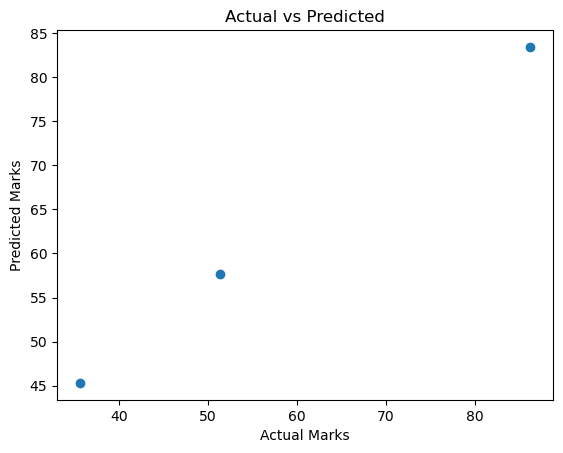

In [28]:


plt.scatter(y_test, pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted")

plt.savefig("plot_actual_vs_predicted.png")
plt.show()